# Example-04: Amplitude estimation

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example amplitude estimation loop is described
# Amplitude and its error is estimated for given frequency using different methods

frequency= 0.536883099, spread=1.37250775e-16, error=2.56151871e-13


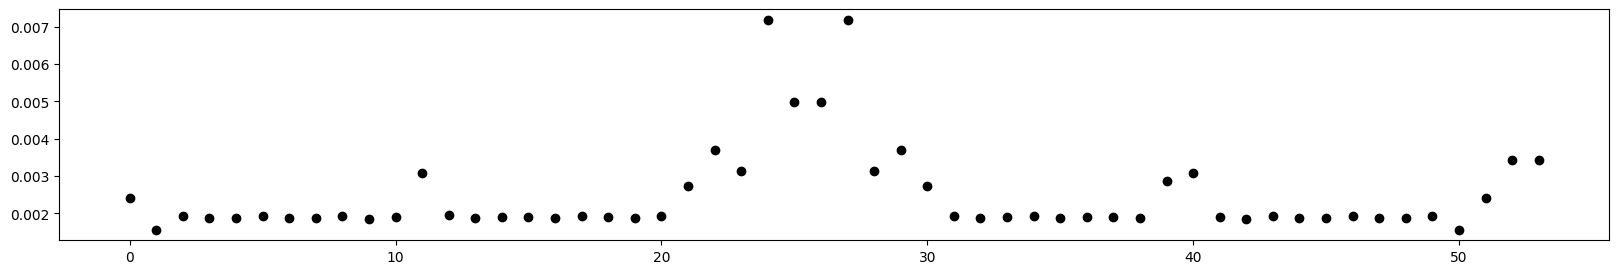

In [4]:
# Estimate reference parameters

# Set window

length = 4096
w = Window(length, 'cosine_window', 5.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Estimate frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency

# Estimate amplitude for given frequency

h = Decomposition(d)
result, _ = h.harmonic_sum(frequency, w.window, d.data)
_, _, amplitude, phase = result.T

# Check maximum reconstruction error

result = []
for a, b in zip(amplitude, phase):
    result.append(Data.make_harmonic(length, frequency, a=a, b=b, dtype=dtype, device=device))
result = torch.stack(result)
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}, error={(d.data - result).abs().max().item():12.9}')

# Plot amplitude

plt.figure(figsize=(20, 3))
plt.scatter(range(54), amplitude.cpu(), color='black')
plt.show()

In [5]:
# Real TbT data length is limited by decoherence
# In this example 1024 turns are used for frequency estimation and only 256 for amplitude

# Set window

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Add random noise

n = 1.0E-6*(25.0 + 75.0*torch.rand(54, dtype=dtype, device=device))
d.add_noise(n)
d.data.copy_(d.work)

# Estimate frequency (average over signals)

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}')

frequency= 0.536883032, spread=1.11278246e-06


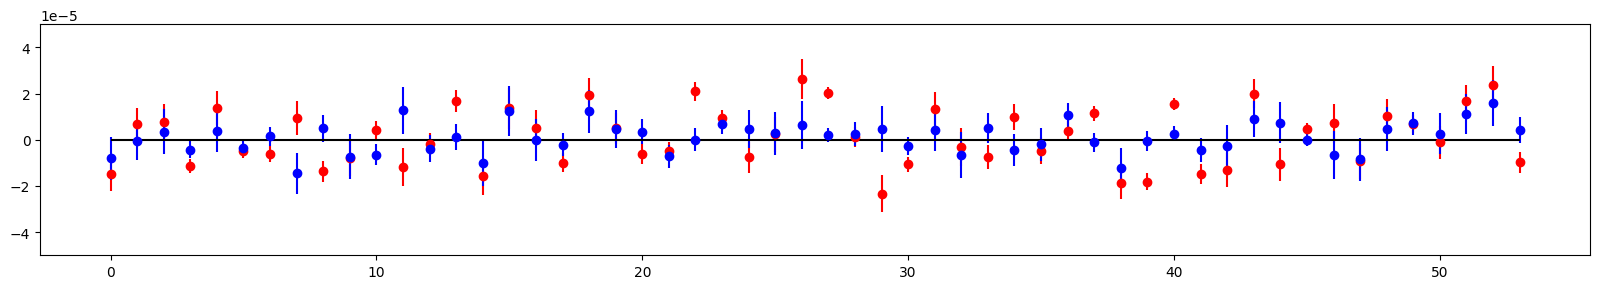

tensor(5.873034807954e-04, dtype=torch.float64)
tensor(2.946756360807e-04, dtype=torch.float64)


In [6]:
# Amplitude (and its error) can be estimated using harmonic_amplitude method

dec = Decomposition(d)

# Estimate amplitude and its spread using error propogation without window (noise is estimated using optimal SVD truncation)

out1, err1, _ = dec.harmonic_amplitude(frequency, length=256, order=0.0, error=True, sigma_frequency=spread)

# Estimate amplitude and its spread using error propogation with window
# Note, fractional window order can be used too, e.g. 0.5

out2, err2, _ = dec.harmonic_amplitude(frequency, length=256, order=1.0, error=True, sigma_frequency=spread)

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out1-amplitude).cpu().numpy(), yerr=err1.cpu().numpy(), fmt=' ', marker='o', color='red')
plt.errorbar(range(54), (out2-amplitude).cpu().numpy(), yerr=err2.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

print((out1 - amplitude).abs().sum())
print((out2 - amplitude).abs().sum())

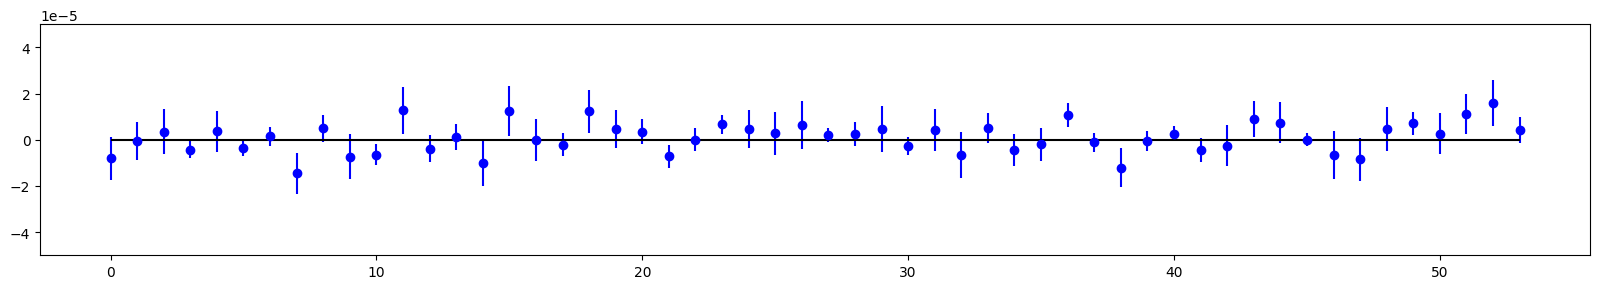

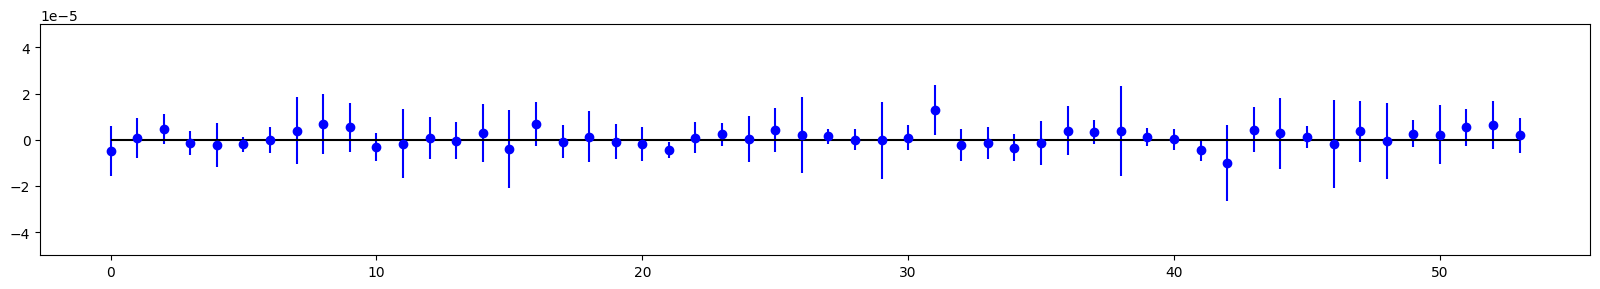

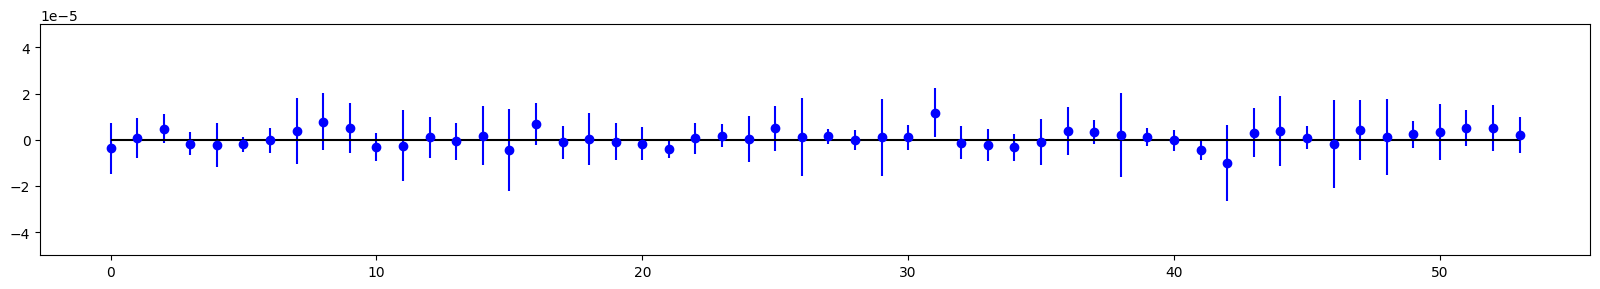

tensor(2.946756360807e-04, dtype=torch.float64)
tensor(1.556087787642e-04, dtype=torch.float64)
tensor(1.501409733753e-04, dtype=torch.float64)


In [7]:
# Sampling can be used to improve estimation accuracy (sampling reduce effect of bias)

dec = Decomposition(d)

# Estimate amplitude and its spread using error propogation

out1, err1, _ = dec.harmonic_amplitude(frequency, length=256, order=1.0, error=True, sigma_frequency=spread)

# Estimate amplitude and its spread from shifted samples
out2, err2, _ = dec.harmonic_amplitude(frequency, length=128, order=1.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, method='none')
out3, err3, _ = dec.harmonic_amplitude(frequency, length=128, order=1.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, method='noise')

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out1-amplitude).cpu().numpy(), yerr=err1.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out2-amplitude).cpu().numpy(), yerr=err2.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out3-amplitude).cpu().numpy(), yerr=err3.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

print((out1 - amplitude).abs().sum())
print((out2 - amplitude).abs().sum())
print((out3 - amplitude).abs().sum())

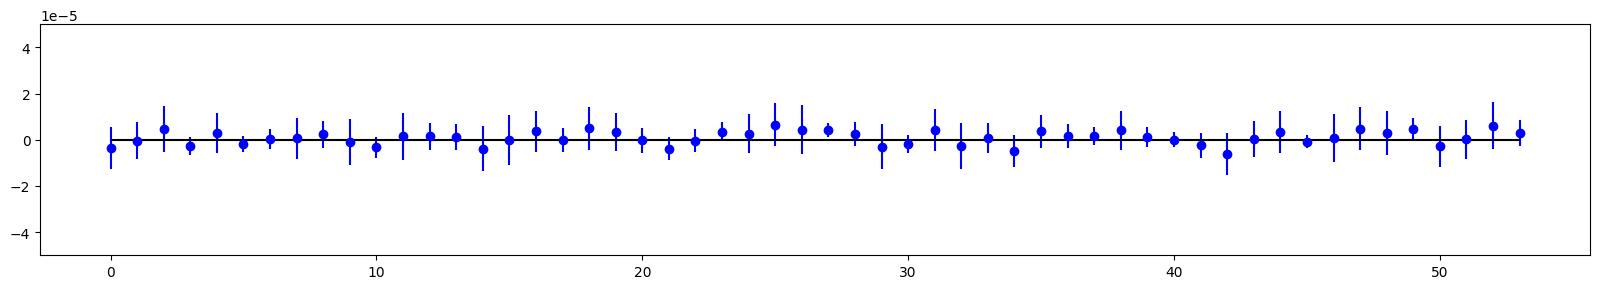

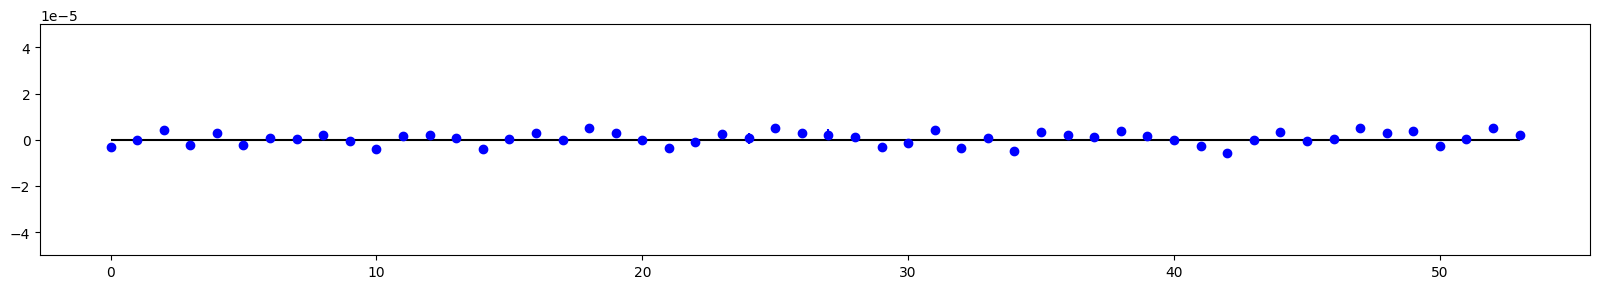

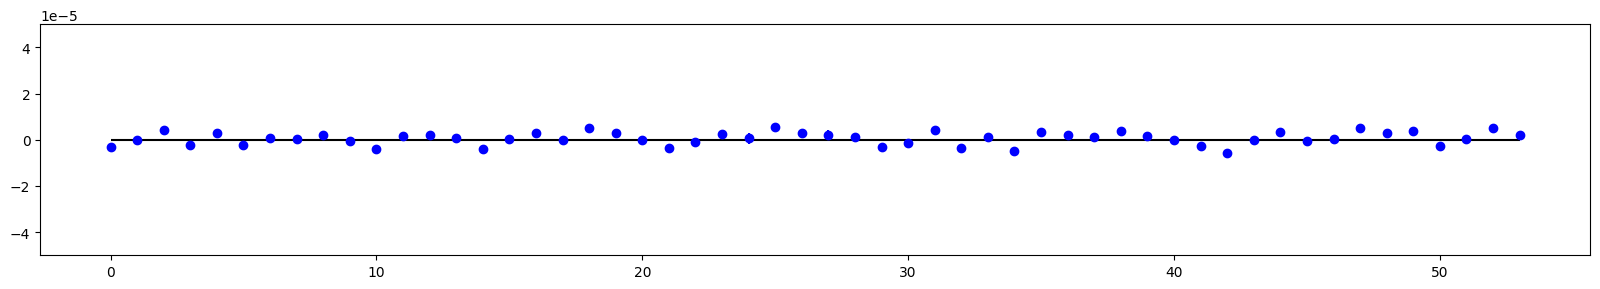

tensor(1.392229778278e-04, dtype=torch.float64)
tensor(1.247371801433e-04, dtype=torch.float64)
tensor(1.246479567945e-04, dtype=torch.float64)


In [8]:
# Filter data (full avaliable length is used)

flt = Filter(d)
flt.filter_svd(rank=2)
flt.filter_hankel(rank=2, random=True, buffer=16, count=16)

# Estimate amplitude

dec = Decomposition(d)
out1, err1, _ = dec.harmonic_amplitude(frequency, length=256, order=1.0, error=True, sigma_frequency=spread)
out2, err2, _ = dec.harmonic_amplitude(frequency, length=128, order=1.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, method='none')
out3, err3, _ = dec.harmonic_amplitude(frequency, length=128, order=1.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, method='noise')

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out1-amplitude).cpu().numpy(), yerr=err1.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out2-amplitude).cpu().numpy(), yerr=err2.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out3-amplitude).cpu().numpy(), yerr=err3.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-5, +5.0E-5)
plt.show()

print((out1 - amplitude).abs().sum())
print((out2 - amplitude).abs().sum())
print((out3 - amplitude).abs().sum())

d.reset()

# Note, with filtering, error estimations from sampled signals might be underestimated depending on window order